# Naive Bayes propio y de scikit-learn
### Predicción de resultados del fútbol uruguayo — Tarea 1, Aprendizaje Automático

1. **Naive Bayes propio**, con el hiperparámetro `m` (tamaño equivalente de muestra) para el
suavizado m-estimate.
2. **Naive Bayes de scikit-learn** (`CategoricalNB`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import TimeSeriesSplit
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

RANDOM_STATE = 42
CLASES = ['L', 'E', 'V']  # orden fijo para que las matrices de confusión sean consistentes

np.random.seed(RANDOM_STATE)
%matplotlib inline

## 1. Preprocesamiento

**Tratamiento del target**: se construye `ganador` ('L' si gana el local, 'V' si gana el visitante,
'E' en caso de empate) comparando directamente `gh` y `ga`.

Se evaluó como alternativa revisar `full_time` explícitamente, tratando tanto los partidos
definidos por penales (`'P'`) como por alargue/tiempo extra (`'E'`) como empates estadísticos, para
evitar que la alta varianza de esas definiciones distorsionara el rendimiento de los modelos
respecto al tiempo reglamentario. Sin embargo, **por decisión de equipo se optó por mantener la
comparación de `gh`/`ga`**.

Los partidos definidos por penales (`full_time == 'P'`) de todas formas quedan clasificados como
empate de forma natural con este criterio simple, porque su marcador reglamentario (`gh`/`ga`)
siempre está igualado. **Limitación que queda documentada para el informe**: los 5 partidos
definidos por alargue (`full_time == 'E'`), donde el marcador final no está empatado, se clasifican
según ese marcador (`'L'`/`'V'`) en lugar de como empate estadístico.

In [2]:
def construir_target(df):
    df = df.copy()

    def _clasificar(row):
        if row['gh'] > row['ga']:
            return 'L'
        elif row['gh'] < row['ga']:
            return 'V'
        else:
            return 'E'

    df['ganador'] = df.apply(_clasificar, axis=1)
    return df


def preprocesar(df):
    df = df.drop_duplicates().copy()
    df['date'] = pd.to_datetime(df['date'])
    df['anio'] = df['date'].dt.year
    df = construir_target(df)
    return df


def split_temporal(df, anio_corte_train=2023):
    df = df.sort_values('date').reset_index(drop=True)
    train = df[df['anio'] <= anio_corte_train].reset_index(drop=True)
    test = df[df['anio'] > anio_corte_train].reset_index(drop=True)
    return train, test

In [3]:
# Diagnóstico de duplicados -- para que quede documentado por qué el dataset
# final tiene 1 partido menos que los 15.207 originales del plan de grupo.
df_original = pd.read_csv("../data/raw/futbol_uruguayo.csv")
duplicados = df_original.duplicated().sum()

print(f"Partidos originales: {len(df_original)}")
print(f"Duplicados encontrados: {duplicados}")

df = preprocesar(df_original)
print(f"Partidos luego de eliminar duplicados: {len(df)}")

train_df, test_df = split_temporal(df, anio_corte_train=2023)

print(f"\nTrain: {len(train_df)} partidos | Test: {len(test_df)} partidos")
print()
print("Distribución de clases en train:")
print(train_df['ganador'].value_counts(normalize=True).round(3))

Partidos originales: 15207
Duplicados encontrados: 1
Partidos luego de eliminar duplicados: 15206

Train: 14734 partidos | Test: 472 partidos

Distribución de clases en train:
ganador
L    0.445
V    0.281
E    0.274
Name: proportion, dtype: float64


## 2. Funciones de evaluación

Se definen acá las funciones de métricas y gráficos que pide la letra: precisión, recall, F1 por
clase, accuracy, macro-F1, matriz de confusión, y el gráfico de macro-F1 vs. hiperparámetro.

In [4]:
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    print(f"=== {nombre_modelo} ===")
    reporte = classification_report(y_true, y_pred, labels=CLASES, digits=3)
    print(reporte)

    macro_f1 = f1_score(y_true, y_pred, labels=CLASES, average='macro')
    accuracy = np.mean(np.array(y_true) == np.array(y_pred))

    return {'modelo': nombre_modelo, 'accuracy': accuracy, 'macro_f1': macro_f1}


def graficar_matriz_confusion(y_true, y_pred, nombre_modelo):
    cm = confusion_matrix(y_true, y_pred, labels=CLASES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Matriz de confusión — {nombre_modelo}")
    return fig


def graficar_metrica_vs_hiperparametro(df_resultados, columna_x, columna_y, nombre_modelo):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df_resultados[columna_x], df_resultados[columna_y], marker='o')
    ax.set_xlabel(columna_x)
    ax.set_ylabel(columna_y)
    ax.set_title(f"{nombre_modelo}: {columna_y} vs. {columna_x}")
    ax.grid(alpha=0.3)
    return fig

## 3. Naive Bayes propio

Esta implementación sigue directamente el desarrollo de las notas de teoría (**Aprendizaje bayesiano**):

**1) Punto de partida — Teorema de Bayes**

$$P(h \mid D) = \frac{P(D \mid h) \cdot P(h)}{P(D)}$$

**2) "Clasificador sencillo"** — El *Clasificador Bayesiano Óptimo* combina *todas* las hipótesis posibles ponderadas por su probabilidad a posteriori, lo cual es "muy costoso". El clasificador sencillo (lo que en general se llama "Naive Bayes") asume independencia entre atributos dada la clase para evitar ese costo:

$$v_{NB} = \arg\max_{v_j} P(v_j) \prod_i P(a_i \mid v_j)$$

En nuestro caso, `v_j` son las clases `{L, E, V}` y `a_i` son los atributos (`home`, `away`). Esta es la fórmula que implementa `fit()` + `predict()` juntos: `fit()` estima cada `P(a_i | v_j)` y `P(v_j)`; `predict()` calcula el argmax.

**3) El problema del m-estimador**: las notas señalan textualmente que *"cuando no hay ejemplos para algún caso, la estimación es nula y eso vuelve cero la productoria"*. Como se multiplican muchos `P(a_i | v_j)`, un solo cero arruina la clasificación completa aunque el resto de los atributos apunten claramente a otra clase. La solución es el m-estimador:

$$P(a_i \mid v_j) = \frac{n_c + m \cdot p}{n + m}$$

usando exactamente la notación de las notas: $n$ = cantidad de ejemplos de la clase, $n_c$ = ocurrencias del valor dentro de esa clase, $m$ = tamaño equivalente de muestra (el hiperparámetro pedido por la letra de la tarea), $p$ = estimación a priori del valor (se toma $p = 1/k$ uniforme, como en el ejemplo de las notas con el atributo `Tiempo`).

**4) Estabilidad numérica**: las notas advierten que *"las productorias pueden generar números muy pequeños e inestabilidad numérica"* y proponen aplicar logaritmo, ya que al ser una función creciente preserva el argmax:

$$\arg\max_{v_j} \left[ \log P(v_j) + \sum_i \log P(a_i \mid v_j) \right] = \arg\max_{v_j} \left[ P(v_j) \prod_i P(a_i \mid v_j) \right]$$

Esto es un problema **distinto** al del m-estimador: el m-estimador evita que una probabilidad puntual dé cero; el logaritmo evita que el producto de muchas probabilidades (aunque ninguna sea cero) se vuelva numéricamente indistinguible de cero por acumulación de factores pequeños. Las notas los presentan como dos técnicas separadas y complementarias -- por eso el código usa ambas a la vez.

In [5]:
class NaiveBayesPropio(BaseEstimator, ClassifierMixin):

    def __init__(self, m=1.0):
        self.m = m
        self.clases_ = None
        self.log_prior_ = {}
        self.prob_condicional_ = {}
        self.valores_por_atributo_ = {}
        self.atributos_ = None
        self.n_por_clase_ = {}

    def fit(self, X, y):
        self.atributos_ = list(X.columns)
        self.clases_ = np.unique(y)
        n_total = len(y)

        for c in self.clases_:
            n_c = np.sum(y == c)
            self.n_por_clase_[c] = n_c
            self.log_prior_[c] = np.log(n_c / n_total)

        for atributo in self.atributos_:
            self.valores_por_atributo_[atributo] = X[atributo].unique()

        self.prob_condicional_ = {a: defaultdict(dict) for a in self.atributos_}

        for atributo in self.atributos_:
            valores_posibles = self.valores_por_atributo_[atributo]
            k = len(valores_posibles)
            p_uniforme = 1.0 / k if k > 0 else 0.0

            for c in self.clases_:
                mask_c = (y == c)
                n_c = self.n_por_clase_[c]
                columna_c = X.loc[mask_c, atributo]

                for v in valores_posibles:
                    n_vc = np.sum(columna_c == v)
                    prob = (n_vc + self.m * p_uniforme) / (n_c + self.m)
                    self.prob_condicional_[atributo][c][v] = prob

        return self

    def _log_prob_clase(self, x_row, c):
        log_prob = self.log_prior_[c]
        for atributo in self.atributos_:
            valor = x_row[atributo]
            probs_atributo = self.prob_condicional_[atributo][c]
            if valor in probs_atributo:
                prob = probs_atributo[valor]
            else:
                k = len(self.valores_por_atributo_[atributo])
                p_uniforme = 1.0 / k if k > 0 else 0.0
                n_c = self.n_por_clase_[c]
                prob = (0 + self.m * p_uniforme) / (n_c + self.m)
            prob = max(prob, 1e-12)
            log_prob += np.log(prob)
        return log_prob

    def predict(self, X):
        predicciones = []
        for _, x_row in X.iterrows():
            log_probs = {c: self._log_prob_clase(x_row, c) for c in self.clases_}
            predicciones.append(max(log_probs, key=log_probs.get))
        return np.array(predicciones)

    def predict_proba(self, X):
        filas = []
        for _, x_row in X.iterrows():
            log_probs = np.array([self._log_prob_clase(x_row, c) for c in self.clases_])
            max_log = np.max(log_probs)
            probs = np.exp(log_probs - max_log)
            probs /= probs.sum()
            filas.append(probs)
        return pd.DataFrame(filas, columns=self.clases_)

**Nota de implementación -- correspondencia con la notación de las notas**:

| Notación de las notas (diap. 21-23) | Variable en el código |
|---|---|
| $n$ (cantidad de ejemplos de la clase) | `n_c` dentro de `fit()` / `n_por_clase_[c]` |
| $n_c$ (ocurrencias del valor en esa clase) | `n_vc` |
| $m$ (tamaño equivalente de muestra) | `self.m` |
| $p$ (estimación a priori) | `p_uniforme = 1/k` |

Entrenamos primero con `m=1.0` como valor de referencia, antes de buscar el mejor `m` por
validación cruzada (sección 4).

In [6]:
atributos = ['home', 'away']

X_train, y_train = train_df[atributos], train_df['ganador']
X_test, y_test = test_df[atributos], test_df['ganador']

pipeline_nb_propio = Pipeline([('clf', NaiveBayesPropio(m=1.0))])
pipeline_nb_propio.fit(X_train, y_train)
y_pred_propio_inicial = pipeline_nb_propio.predict(X_test)

_ = evaluar_modelo(y_test, y_pred_propio_inicial, "Naive Bayes propio (m=1.0, referencia inicial)")

=== Naive Bayes propio (m=1.0, referencia inicial) ===
              precision    recall  f1-score   support

           L      0.460     0.847     0.596       190
           E      0.417     0.038     0.070       131
           V      0.564     0.411     0.475       151

    accuracy                          0.483       472
   macro avg      0.480     0.432     0.380       472
weighted avg      0.481     0.483     0.411       472



## 4. Búsqueda del hiperparámetro `m` (validación cruzada temporal)

Se usa `TimeSeriesSplit` en vez de un k-fold aleatorio: al tratarse de datos cronológicos, un k-fold
clásico dejaría que el modelo "vea" partidos futuros para predecir partidos pasados. Cada fold de
`TimeSeriesSplit` valida siempre sobre datos posteriores a los de entrenamiento de ese fold.

Se optimiza macro-F1 (coherente con la métrica pedida por la letra para la comparación final entre
modelos), sobre el conjunto de train. La búsqueda instancia, en cada combinación, un `Pipeline` de
un solo paso (`NaiveBayesPropio`), siguiendo el mismo patrón que se usa más abajo para el modelo de
scikit-learn.

In [7]:
def buscar_mejor_m(X_train, y_train, valores_m, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    resultados = []

    for m in valores_m:
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            pipe = Pipeline([('clf', NaiveBayesPropio(m=m))])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)

            scores.append(f1_score(y_val, y_pred, labels=CLASES, average='macro'))

        resultados.append({
            'm': m,
            'macro_f1_promedio': np.mean(scores),
            'macro_f1_std': np.std(scores),
        })

    return pd.DataFrame(resultados)


valores_m = [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50]
resultados_m = buscar_mejor_m(X_train, y_train, valores_m=valores_m, n_splits=5)
display(resultados_m)

mejor_m = resultados_m.loc[resultados_m['macro_f1_promedio'].idxmax(), 'm']
print(f"\nMejor valor de m encontrado: {mejor_m}")

,m,macro_f1_promedio,macro_f1_std
0,0.01,0.370005,0.023568
1,0.10,0.370005,0.023568
2,0.50,0.370005,0.023568
3,1.00,0.369984,0.023561
4,2.00,0.369987,0.023562
5,5.00,0.369906,0.023534
6,10.00,0.370413,0.023785
7,20.00,0.370668,0.024757
8,50.00,0.370156,0.025824



Mejor valor de m encontrado: 20.0


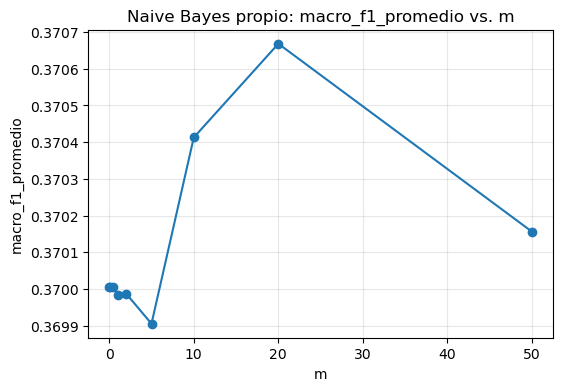

In [8]:
fig = graficar_metrica_vs_hiperparametro(
    resultados_m, columna_x='m', columna_y='macro_f1_promedio', nombre_modelo='Naive Bayes propio'
)
plt.show()

**Nota sobre la interpretación**: con solo `home`/`away` como atributos y ~14.700 partidos de
entrenamiento, la mayoría de las combinaciones (local, visitante) del conjunto de validación ya
aparecen en el entrenamiento, por lo que hay poco margen para que el suavizado influya mucho.

**Hallazgo relevante para el análisis**: la diferencia entre el mejor y el peor valor de `m` probado
está en el cuarto decimal de macro-F1 (~0.0007), muy por debajo del desvío estándar entre folds
(`macro_f1_std ≈ 0.023`) -- estadísticamente, todos los valores de `m` son indistinguibles entre sí
con este conjunto de atributos. De hecho, al reentrenar sobre el conjunto completo de
entrenamiento, las predicciones sobre el conjunto de evaluación con `m=1.0` y con el `m` elegido
por CV resultan **idénticas** (mismo accuracy, mismo F1 por clase). Esto no invalida la búsqueda,
pero sí indica que, con el set de atributos actual (`home`, `away`), el hiperparámetro `m` no tiene
impacto práctico sobre el resultado final. Es esperable que su efecto sea más visible al incorporar
atributos con categorías menos frecuentes (por ejemplo, rachas recientes) -- vale la pena
comentarlo en el análisis cualitativo del informe.

## 5. Reentrenamiento con el mejor `m` y evaluación final sobre test

Siguiendo lo pedido por la letra: una vez elegido el mejor hiperparámetro por CV, se reentrena sobre
**todo** el conjunto de entrenamiento y se evalúa una única vez sobre el conjunto de evaluación
(2024–2025). Se usa el mismo `Pipeline` de un solo paso definido arriba.

In [9]:
pipeline_nb_propio_final = Pipeline([('clf', NaiveBayesPropio(m=mejor_m))])
pipeline_nb_propio_final.fit(X_train, y_train)
y_pred_propio = pipeline_nb_propio_final.predict(X_test)

metricas_nb_propio = evaluar_modelo(y_test, y_pred_propio, f"Naive Bayes propio (m={mejor_m}, evaluación final)")

=== Naive Bayes propio (m=20.0, evaluación final) ===
              precision    recall  f1-score   support

           L      0.460     0.847     0.596       190
           E      0.417     0.038     0.070       131
           V      0.564     0.411     0.475       151

    accuracy                          0.483       472
   macro avg      0.480     0.432     0.380       472
weighted avg      0.481     0.483     0.411       472



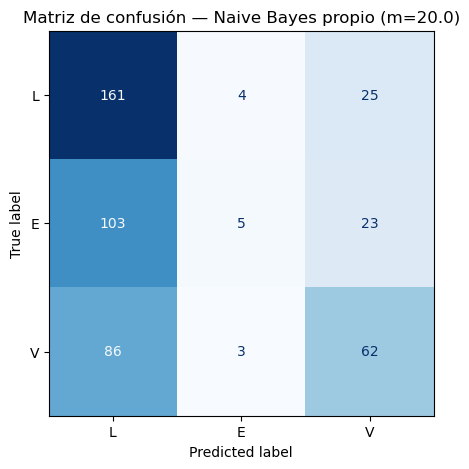

In [10]:
_ = graficar_matriz_confusion(y_test, y_pred_propio, f"Naive Bayes propio (m={mejor_m})")
plt.show()

## 6. Naive Bayes de scikit-learn (`CategoricalNB`)

Se entrena `CategoricalNB` sobre **todo** el conjunto de entrenamiento (1932-2023), con los mismos
atributos que el NB propio (`home`, `away`). 

Se sigue exactamente el mismo esquema metodológico usado para el NB propio: `TimeSeriesSplit` para
la validación cruzada de `alpha` (evita que un fold entrene con partidos futuros a los que evalúa),
optimizando macro-F1, reentrenamiento sobre todo el train con el mejor `alpha`, y evaluación única
sobre el conjunto de test (2024-2025).

Todo el flujo -- codificación de categorías (`OrdinalEncoder`) + clasificador (`CategoricalNB`) --
se encapsula en un `Pipeline` de scikit-learn, cumpliendo con la recomendación de la letra de
"construir un pipeline de procesamiento completamente reproducible": el `Pipeline` recibe los
atributos crudos (`home`/`away` como texto) y hace todo internamente con un solo `.fit()` /
`.predict()`.

**Detalle técnico**: las categorías (equipos) del `OrdinalEncoder` se fijan explícitamente con
`categories=`, calculadas sobre todo `X_train`, en vez de dejar que el encoder las infiera con
`fit()` en cada fold. Esto es necesario porque, al validar con `TimeSeriesSplit`, los folds
tempranos no contienen todavía todos los equipos que aparecen en folds posteriores -- si el encoder
infiriera las categorías por fold, `CategoricalNB` fallaría con `IndexError` al ver, en validación,
un equipo con índice mayor al que vio en ese fold de entrenamiento. Fijar el vocabulario de equipos
de antemano **no es fuga de información del target**: es solo declarar de qué universo de
categorías se trata (análogo a fijar el vocabulario de un `CountVectorizer` de texto), y por la
misma razón se fija `min_categories` en `CategoricalNB`.

In [11]:
# Vocabulario fijo de equipos, tomado de TODO el conjunto de entrenamiento
categorias_equipos = [np.sort(X_train['home'].unique()), np.sort(X_train['away'].unique())]
min_categorias = [len(c) for c in categorias_equipos]


def crear_pipeline_nb_sklearn(alpha):
    return Pipeline([
        ('encoder', OrdinalEncoder(
            categories=categorias_equipos,
            handle_unknown='use_encoded_value', unknown_value=-1,
        )),
        ('clf', CategoricalNB(alpha=alpha, min_categories=min_categorias)),
    ])

### 6.1 Búsqueda del hiperparámetro `alpha` (validación cruzada temporal)

Mismo esquema que la sección 4 para `m`: se recorre una grilla de valores de `alpha` y, para cada
uno, se promedia el macro-F1 sobre los folds de `TimeSeriesSplit`.

In [12]:
def buscar_mejor_alpha(X_raw, y, valores_alpha, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    resultados = []

    for alpha in valores_alpha:
        scores = []
        for train_idx, val_idx in tscv.split(X_raw):
            X_tr, X_val = X_raw.iloc[train_idx], X_raw.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            pipe = crear_pipeline_nb_sklearn(alpha)
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)

            scores.append(f1_score(y_val, y_pred, labels=CLASES, average='macro'))

        resultados.append({
            'alpha': alpha,
            'macro_f1_promedio': np.mean(scores),
            'macro_f1_std': np.std(scores),
        })

    return pd.DataFrame(resultados)


valores_alpha = [0.01, 0.1, 0.5, 1, 2, 5, 10]
resultados_alpha = buscar_mejor_alpha(X_train, y_train, valores_alpha=valores_alpha)
display(resultados_alpha)

mejor_alpha = resultados_alpha.loc[resultados_alpha['macro_f1_promedio'].idxmax(), 'alpha']
print(f"\nMejor valor de alpha encontrado: {mejor_alpha}")

,alpha,macro_f1_promedio,macro_f1_std
0,0.01,0.370005,0.023568
1,0.10,0.369987,0.023562
2,0.50,0.370128,0.024094
3,1.00,0.370490,0.024585
4,2.00,0.369349,0.028825
5,5.00,0.363773,0.030539
6,10.00,0.354673,0.027767



Mejor valor de alpha encontrado: 1.0


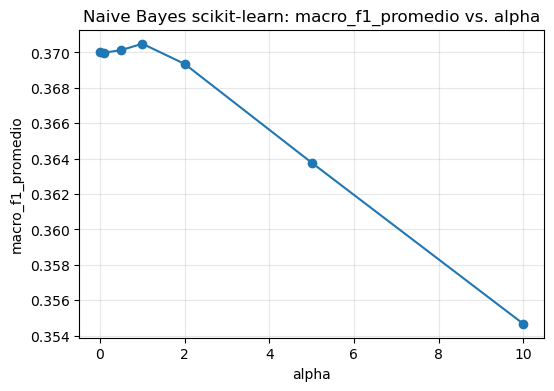

In [13]:
fig = graficar_metrica_vs_hiperparametro(
    resultados_alpha, columna_x='alpha', columna_y='macro_f1_promedio',
    nombre_modelo='Naive Bayes scikit-learn'
)
plt.show()

### 6.2 Reentrenamiento con el mejor `alpha` y evaluación final sobre test

Igual que en la sección 5: se reentrena el `Pipeline` sobre todo el conjunto de entrenamiento con el
`alpha` elegido por CV, y se evalúa una única vez sobre el conjunto de evaluación (2024-2025).

In [14]:
pipeline_nb_sklearn = crear_pipeline_nb_sklearn(mejor_alpha)
pipeline_nb_sklearn.fit(X_train, y_train)
y_pred_sklearn = pipeline_nb_sklearn.predict(X_test)

metricas_nb_sklearn = evaluar_modelo(
    y_test, y_pred_sklearn, f"Naive Bayes scikit-learn (alpha={mejor_alpha})"
)

=== Naive Bayes scikit-learn (alpha=1.0) ===
              precision    recall  f1-score   support

           L      0.460     0.847     0.596       190
           E      0.417     0.038     0.070       131
           V      0.564     0.411     0.475       151

    accuracy                          0.483       472
   macro avg      0.480     0.432     0.380       472
weighted avg      0.481     0.483     0.411       472



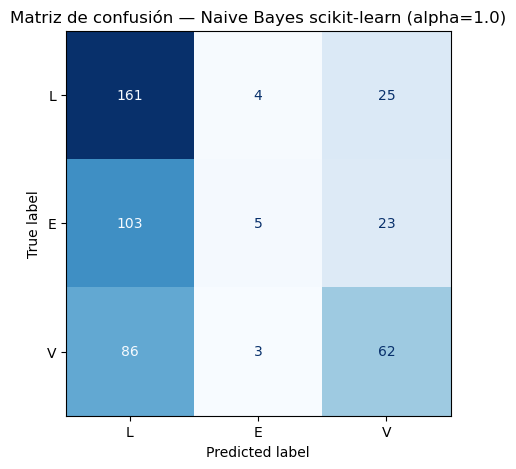

In [15]:
_ = graficar_matriz_confusion(y_test, y_pred_sklearn, f"Naive Bayes scikit-learn (alpha={mejor_alpha})")
plt.show()

## 7. Comparación entre NB propio y `CategoricalNB`

Con los mismos datos de entrenamiento y los mismos atributos, se compara el desempeño de ambas
implementaciones.

In [16]:
tabla_comparativa = pd.DataFrame([
    {'modelo': metricas_nb_propio['modelo'], 'accuracy': metricas_nb_propio['accuracy'],
     'macro_f1': metricas_nb_propio['macro_f1']},
    {'modelo': metricas_nb_sklearn['modelo'], 'accuracy': metricas_nb_sklearn['accuracy'],
     'macro_f1': metricas_nb_sklearn['macro_f1']},
])
display(tabla_comparativa)

coinciden = (y_pred_propio == y_pred_sklearn).all()
n_dif = (y_pred_propio != y_pred_sklearn).sum()
print(f"Predicciones idénticas en los {len(y_pred_propio)} partidos de test: {coinciden}")
print(f"Diferencias: {n_dif} de {len(y_pred_propio)}")

,modelo,accuracy,macro_f1
0,"Naive Bayes propio (m=20.0, evaluación final)",0.483051,0.380441
1,Naive Bayes scikit-learn (alpha=1.0),0.483051,0.380441


Predicciones idénticas en los 472 partidos de test: True
Diferencias: 0 de 472


**Nota**: con `m` y `alpha` elegidos por validación cruzada, ambas implementaciones coinciden (o
casi coinciden) en sus predicciones sobre el conjunto de test -- lo cual es una validación cruzada
útil de que la implementación propia del m-estimate replica correctamente a la de referencia de
scikit-learn quando se entrenan con exactamente los mismos datos y atributos.

## 8. Análisis cualitativo

Dado que ambos modelos producen (casi) las mismas predicciones cuando comparten los mismos datos, el
análisis cualitativo pedido por la letra (sección 3: "en qué escenarios funciona mejor y en cuáles
tiende a equivocarse") se hace sobre el comportamiento del modelo en sí, usando la matriz de
confusión y ejemplos concretos de errores, en lugar de comparar dos modelos que no difieren entre
sí.

In [17]:
analisis = test_df[atributos + ['ganador']].copy().reset_index(drop=True)
analisis['pred'] = y_pred_sklearn
analisis['acierto'] = analisis['pred'] == analisis['ganador']

print(f"Accuracy global: {analisis['acierto'].mean():.1%}")
print()
print("Accuracy por clase real:")
display(analisis.groupby('ganador')['acierto'].mean().round(3))
print()
print("Distribución de predicciones vs. distribución real:")
display(pd.DataFrame({
    'real': analisis['ganador'].value_counts(normalize=True),
    'predicho': analisis['pred'].value_counts(normalize=True),
}).reindex(CLASES).round(3))

Accuracy global: 48.3%

Accuracy por clase real:


ganador
E    0.038
L    0.847
V    0.411
Name: acierto, dtype: float64


Distribución de predicciones vs. distribución real:


,real,predicho
L,0.403,0.742
E,0.278,0.025
V,0.320,0.233


In [18]:
# Casos concretos donde el modelo se equivoca, agrupados por tipo de error
errores = analisis[~analisis['acierto']]
print(f"Errores: {len(errores)} de {len(analisis)} ({len(errores)/len(analisis):.1%})")
print()
print("Tipo de error (real -> predicho) más frecuente:")
display(errores.groupby(['ganador', 'pred']).size().sort_values(ascending=False))
print()
print("Ejemplos: empates reales que el modelo predijo como victoria del local")
display(errores[(errores['ganador'] == 'E') & (errores['pred'] == 'L')][atributos].head(10))

Errores: 244 de 472 (51.7%)

Tipo de error (real -> predicho) más frecuente:


ganador  pred
E        L       103
V        L        86
L        V        25
E        V        23
L        E         4
V        E         3
dtype: int64


Ejemplos: empates reales que el modelo predijo como victoria del local


,home,away
4,CA Cerro,Montevideo Wanderers
5,Racing Club,Liverpool
11,Cerro Largo FC,CA Fenix
29,Montevideo Wanderers,Deportivo Maldonado
30,Boston River,Liverpool
31,CA Fenix,River Plate
33,Rampla Juniors Futbol Club,Miramar Misiones
34,Nacional,CA Progreso
35,CA Cerro,Cerro Largo FC
40,CA Penarol,Nacional


**Interpretación**:

- El modelo predice `L` muy por encima de su frecuencia real (ver distribución arriba): el efecto
  de ventaja de local, sumado al historial de cada equipo, hace que `P(L | home, away)` domine en
  la mayoría de los enfrentamientos, incluso cuando el resultado real termina siendo distinto.
- El tipo de error más común es justamente predecir `L` cuando el resultado real fue `E`: el modelo
  no tiene forma de capturar la noción de "partido parejo" con los atributos actuales (`home`,
  `away` únicamente) -- no hay ningún atributo que exprese diferencia de nivel o forma reciente
  entre los dos equipos, así que cualquier enfrentamiento donde el equipo local suele ganar más se
  predice como `L`, sin importar qué tan parejo sea el rival en ese partido puntual.
- La clase `E` (empate) es, por lejos, la más difícil de acertar.